<a href="https://colab.research.google.com/github/jerovernay/IMC/blob/main/IMC_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integrantes** \
Reynaldo Martín Peralta Recio, 428/22 \
Jeronimo Vernay, 313/24


# TP I - Trayectorias de Kepler y corrección relativista

Una corrección relativista para el problema de dos cuerpos de Kepler, sistema Sol-planeta, puede describirse en coordenadas polares con la ecuación:
$$
\ddot{u}(θ) + u(θ) - \frac{1}{α} - \delta u²(θ) = 0  
$$
Donde $u(θ) = \frac{1}{r(θ)}$, el Sol se encuentra en el origen, $α$ y $δ$ son constantes. El término con $δ$ es la corrección relativista.

1. Formular el problema como un sistema de orden uno de la forma $\dot{y} = f (θ, y)$. Observar que la variable independiente no es el tiempo sino ángulos en polares.

**Solución**:

Para formular el problema como un sistema de orden 1 de la forma $\dot{y} \,=\,f(\theta , y)$, debemos de definir un vector de estado con la variable independiente $θ$, pues la variable independiente deben de ser los angulos.

Sea:

$$\;y_1(\theta) \, = \, u(\theta) \, = \, \frac{1}{r (\theta)} \quad \text{y} \quad y_2(\theta) \, = \, \dot u(\theta) \quad ⇒ \quad y(\theta) \, = \, (y_1(\theta) \,,\, y_2(\theta)) \\[0.3cm]$$

Luego definimos el campo vectorial $\,f(\theta, y)\,$ al derivar sobre $\dot y: \\[0,2cm]$

$$\dot y \, =\, (\dot y_1\, , \, \dot y_2) \,  $$

Donde:

$$ \dot y_1 \, = \, y_2 $$
$$\dot y_2 \, = \, \ddot u \, = \, -u \, + \frac{1}{\alpha} \, \delta \, u^2 $$ $$ \dot y_2 \, = \, -y_1 \, +\, \frac{1}{\alpha} \, + \, \delta \, y_1^2 \\[0,3cm]$$

Por lo tanto:

$$\dot y \, =\, f(\theta, y)\, = \, (\dot y_1 \, , \,\dot y_2) \, = \, (\,y_2 \, , \,-y_1 \, +\, \frac{1}{\alpha} \, + \, \delta \, y_1^2\,) \\[0,3cm]$$

El estado del sistema queda definido por la inversa de la distancia radial ($\,y_1 = u(\theta)$) y su tasa de cambio respecto al ángulo ($y_2 = \dot{u}(\theta)$). Como el ángulo $\theta$ , la variable independiente, no aparece de forma explicita en las ecuaciones, obtenemos un sistema autónomo no lineal de primer orden.

&nbsp;

2. Resolver el problema de Kepler ($δ = 0$), con condiciones iniciales $r(0) = \frac{α}{1 + ϵ}$ y $\dot{r}(0) = 0$. Donde $ϵ$
es la excentricidad de la órbita: $0 ≤ ϵ < 1$ para orbitas cerradas, $ϵ ≥ 1$ para órbitas abiertas. La
condición $\dot{r}(0) = 0$ (velocidad radial cero) significa que medimos los ángulos a partir del perihelio
(punto más cercano al Sol). \
Graficar soluciones con $α = 1$ para distintos valores de $ϵ$. Observar que pasa cuando $θ > 2π$ (3 o
4 vueltas).

**Solución**:

<>:73: SyntaxWarning: invalid escape sequence '\e'
<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:79: SyntaxWarning: invalid escape sequence '\d'
<>:100: SyntaxWarning: invalid escape sequence '\e'
<>:102: SyntaxWarning: invalid escape sequence '\d'
<>:73: SyntaxWarning: invalid escape sequence '\e'
<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:79: SyntaxWarning: invalid escape sequence '\d'
<>:100: SyntaxWarning: invalid escape sequence '\e'
<>:102: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_15523/1966388481.py:73: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(u, u_dot, color=col, linewidth=2.5, label=f'$\epsilon={eps}$')
/tmp/ipykernel_15523/1966388481.py:77: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f'Desarrollo $\epsilon = {eps}$')
/tmp/ipykernel_15523/1966388481.py:79: SyntaxWarning: invalid escape sequence '\d'
  if ax == axes1[0]: ax.set_ylabel('$\dot{u}$')
/tmp/ipykernel_15523/1966388481.py:100: SyntaxWarning: invalid esca

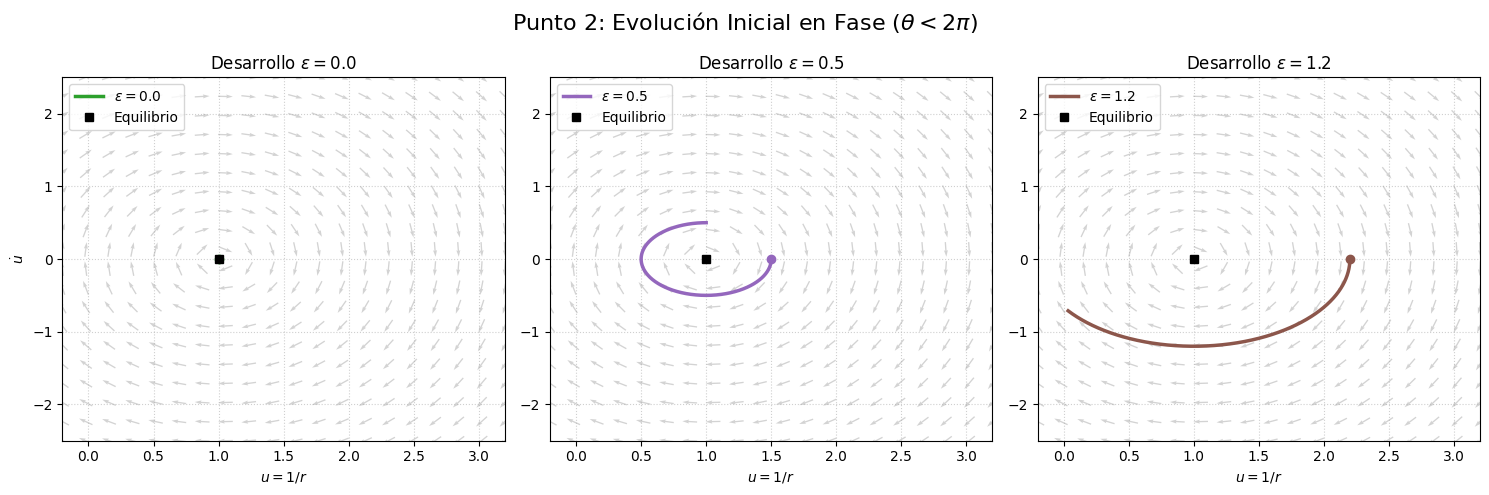

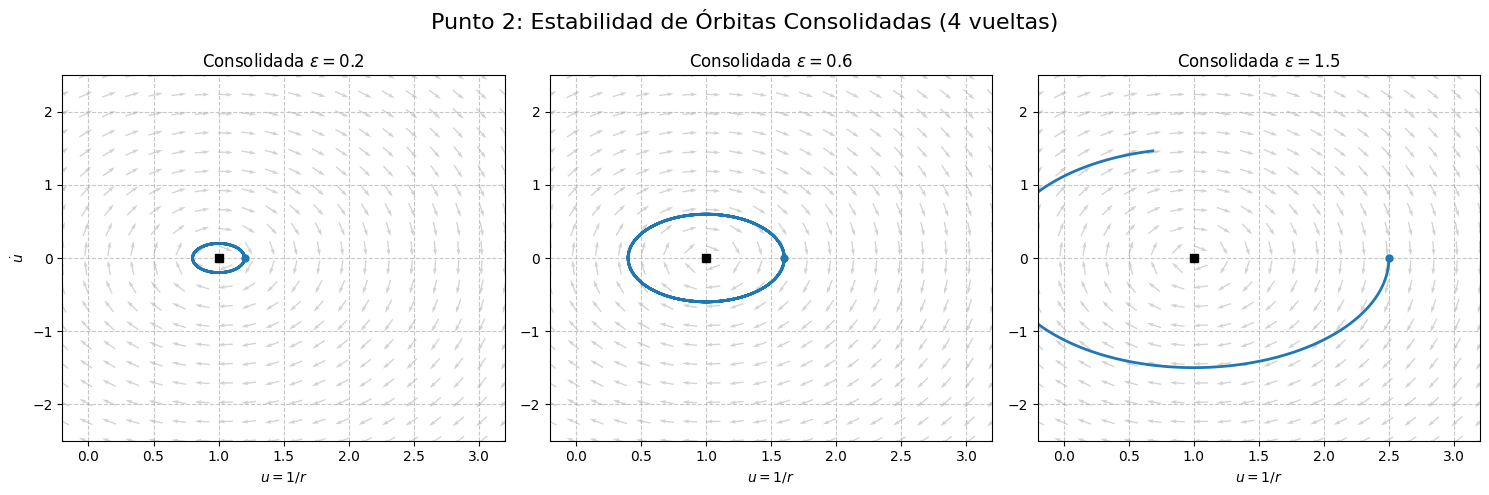

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider

plt.style.use('default')

# --- 1. NÚCLEO MATEMÁTICO ÚNICO ---

def sistema_kepler(theta, y, alpha, delta):
    """Ecuación diferencial general para el caso clásico y relativista"""
    u, u_dot = y
    return [u_dot, -u + 1/alpha + delta * (u**2)]

def integrar_sistema(epsilon, alpha, delta, vueltas, incompleto=False):
    """
    Función maestra para resolver el sistema.
    Devuelve theta, u, y u_dot para poder graficar en cualquier plano.
    """
    u0 = (1 + epsilon) / alpha
    y0 = [u0, 0.0]

    if epsilon < 1:
        # Órbitas cerradas
        theta_lim = 1.5 * np.pi if incompleto else vueltas * 2 * np.pi
        t_span = (0, theta_lim)
    else:
        # Órbitas abiertas (hipérbolas)
        theta_lim = np.arccos(-1.0 / epsilon) - 0.05
        t_span = (-theta_lim if not incompleto else 0, theta_lim)

    t_eval = np.linspace(t_span[0], t_span[1], 2000)

    # Tolerancias estrictas (rtol, atol) muy importantes para que el error
    # numérico no genere una "falsa precesión" en el caso clásico.
    sol = solve_ivp(sistema_kepler, t_span, y0, t_eval=t_eval,
                    args=(alpha, delta), rtol=1e-8, atol=1e-8)

    return sol.t, sol.y[0], sol.y[1] # theta, u, u_dot

def dibujar_quiver(ax, alpha, delta):
    """Dibuja el campo vectorial de fondo en un eje dado."""
    u_min, u_max = -0.2, 3.2
    v_min, v_max = -2.5, 2.5
    u_grid, v_grid = np.meshgrid(np.linspace(u_min, u_max, 20),
                                 np.linspace(v_min, v_max, 20))
    du = v_grid
    dv = -u_grid + 1.0/alpha + delta * (u_grid**2)
    M = np.hypot(du, dv)
    M[M == 0] = 1.0
    ax.quiver(u_grid, v_grid, du/M, dv/M, color="lightgray", pivot="mid", scale=30)
    ax.set_xlim(u_min, u_max)
    ax.set_ylim(v_min, v_max)

# =====================================================================
# --- EJECUCIÓN DE LOS GRÁFICOS ---
# =====================================================================

alpha_base = 1.0
delta_base = 0.0

# --- 2. SET 1: TRAYECTORIAS EN DESARROLLO (theta < 2pi) ---
eps_desarrollo = [0.0, 0.5, 1.2]
colores_desarrollo = ['#2ca02c', '#9467bd', '#8c564b']

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle(r'Punto 2: Evolución Inicial en Fase ($\theta < 2\pi$)', fontsize=16)

for ax, eps, col in zip(axes1, eps_desarrollo, colores_desarrollo):
    dibujar_quiver(ax, alpha_base, delta_base)
    theta, u, u_dot = integrar_sistema(eps, alpha_base, delta_base, vueltas=1, incompleto=True)

    ax.plot(u, u_dot, color=col, linewidth=2.5, label=f'$\epsilon={eps}$')
    ax.plot(u[0], u_dot[0], 'o', color=col, markersize=6) # Inicio
    ax.plot(1.0/alpha_base, 0.0, 'ks', markersize=6, label='Equilibrio')

    ax.set_title(f'Desarrollo $\epsilon = {eps}$')
    ax.set_xlabel('$u = 1/r$')
    if ax == axes1[0]: ax.set_ylabel('$\dot{u}$')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# --- 3. SET 2: ÓRBITAS COMPLETAS (4 Vueltas) ---
eps_completas = [0.2, 0.6, 1.5]

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle(r'Punto 2: Estabilidad de Órbitas Consolidadas (4 vueltas)', fontsize=16)

for ax, eps in zip(axes2, eps_completas):
    dibujar_quiver(ax, alpha_base, delta_base)
    theta, u, u_dot = integrar_sistema(eps, alpha_base, delta_base, vueltas=4, incompleto=False)

    ax.plot(u, u_dot, color='#1f77b4', linewidth=2)
    ax.plot(u[0], u_dot[0], 'o', color='#1f77b4', markersize=5)
    ax.plot(1.0/alpha_base, 0.0, 'ks', markersize=6)

    ax.set_title(f'Consolidada $\epsilon = {eps}$')
    ax.set_xlabel('$u = 1/r$')
    if ax == axes2[0]: ax.set_ylabel('$\dot{u}$')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

3. Resolver el problema relativista para $δ = 0.05$ en las mismas condiciones iniciales del ítem anterior
y comparar. \
El efecto se conoce como precesión del perihelio y las mediciones sobre la órbita de Mercurio fueron
utilizadas por Albert Einstein como evidencia experimental de la Teoría General de la Relatividad.

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_15523/141388620.py:12: SyntaxWarning: invalid escape sequence '\d'
  fig3.suptitle(f'Punto 3: Precesión del Perihelio ($\delta = {delta_rel}$)', fontsize=16)
/tmp/ipykernel_15523/141388620.py:22: SyntaxWarning: invalid escape sequence '\d'
  ax_fase.set_ylabel('$\dot{u}$')


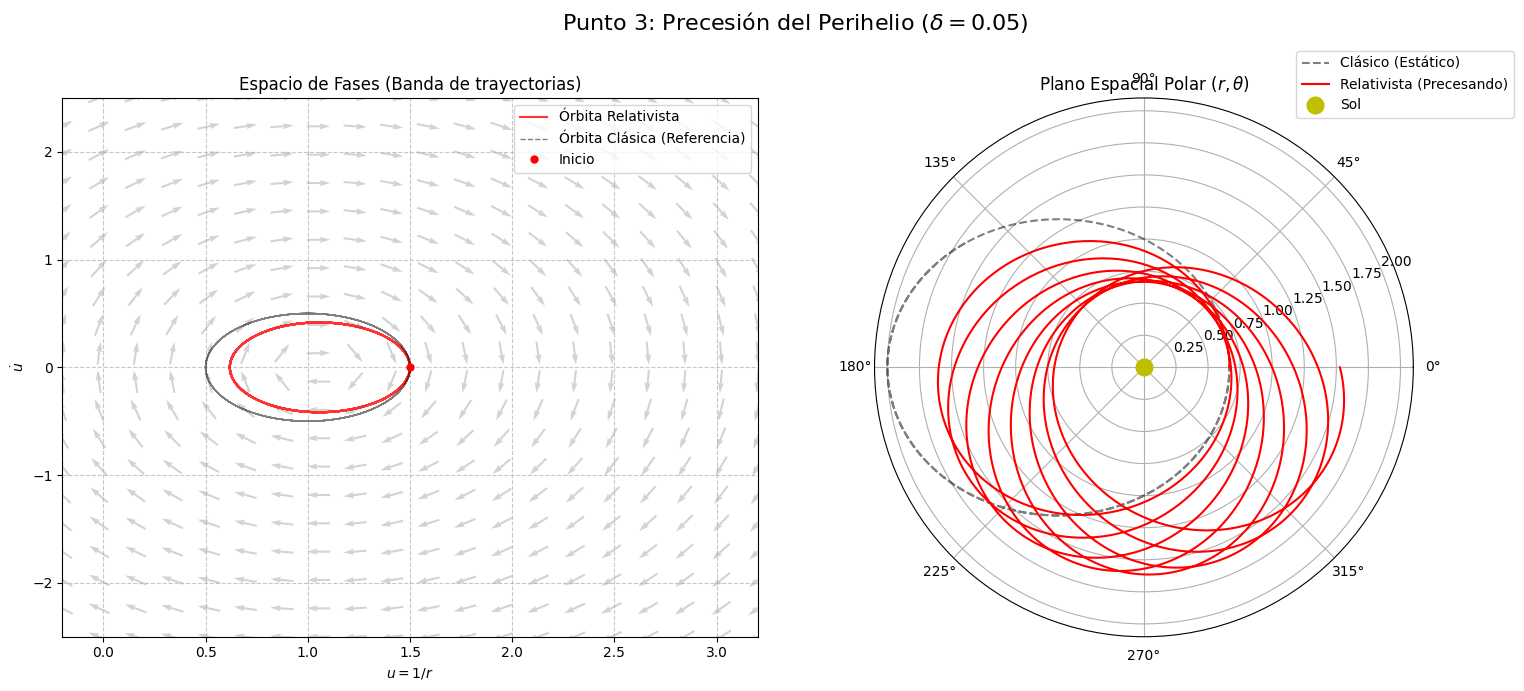

In [2]:
# --- 5. PUNTO 3: EFECTO DE PRECESIÓN RELATIVISTA ---
delta_rel = 0.05  # Perturbación
eps_rel = 0.5     # Excentricidad elíptica
vueltas_rel = 8   # Vueltas suficientes para ver la precesión

# Integramos el caso clásico y el relativista para comparar
theta_cl, u_cl, u_dot_cl = integrar_sistema(eps_rel, alpha_base, 0.0, vueltas=vueltas_rel)
theta_rel, u_rel, u_dot_rel = integrar_sistema(eps_rel, alpha_base, delta_rel, vueltas=vueltas_rel)

# Creamos una figura con dos subplots: El plano de fases y el plano polar
fig3 = plt.figure(figsize=(16, 7))
fig3.suptitle(f'Punto 3: Precesión del Perihelio ($\delta = {delta_rel}$)', fontsize=16)

# Subplot 1: Plano de Fases (El quiver es VITAL acá)
ax_fase = fig3.add_subplot(1, 2, 1)
dibujar_quiver(ax_fase, alpha_base, delta_rel) # Notar que pasamos delta_rel para el quiver
ax_fase.plot(u_rel, u_dot_rel, color='red', linewidth=1.5, alpha=0.8, label='Órbita Relativista')
ax_fase.plot(u_cl, u_dot_cl, 'k--', linewidth=1, alpha=0.5, label='Órbita Clásica (Referencia)')
ax_fase.plot(u_rel[0], u_dot_rel[0], 'ro', markersize=5, label='Inicio')
ax_fase.set_title("Espacio de Fases (Banda de trayectorias)")
ax_fase.set_xlabel('$u = 1/r$')
ax_fase.set_ylabel('$\dot{u}$')
ax_fase.grid(True, linestyle='--', alpha=0.7)
ax_fase.legend()

# Subplot 2: Plano Polar para ver el giro físico
ax_polar = fig3.add_subplot(1, 2, 2, projection='polar')
# Graficamos la última vuelta de la clásica como referencia de adónde "debería" estar
ax_polar.plot(theta_cl[-400:], (1/u_cl)[-400:], 'k--', alpha=0.5, label='Clásico (Estático)')
# Graficamos toda la evolución relativista
ax_polar.plot(theta_rel, 1/u_rel, color='red', linewidth=1.5, label='Relativista (Precesando)')
ax_polar.plot(0, 0, 'yo', markersize=12, label='Sol')
ax_polar.set_title("Plano Espacial Polar ($r, \\theta$)")
ax_polar.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()